# Кросс-валидация, оценка моделей и подбор гиперпараметров

В этом ноутбуке подробно разбираются:

1. Что такое кросс-валидация и, самое главное, **зачем она нужна**.
2. Основные виды кросс-валидации в scikit-learn: `KFold`, `StratifiedKFold`,
   `LeaveOneOut`, `LeavePOut`, `ShuffleSplit`, `StratifiedShuffleSplit`,
   `GroupKFold`, `TimeSeriesSplit`, `RepeatedKFold` и функция `cross_validate`
   — с параметрами, плюсами/минусами и примерами кода.
3. Подбор гиперпараметров: наивный перебор, `GridSearchCV`, `RandomizedSearchCV`,
   Successive Halving и вложенная (nested) кросс-валидация.
4. Практическая функция, определяющая, **репрезентативна ли выборка**
   (adversarial validation).
5. **Coarse-to-fine search** — стратегия «сначала грубо, потом точно» —
   и собственный класс `CoarseToFineSearchCV`, реализующий интерфейс
   `BaseSearchCV` из scikit-learn.

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# mglearn используется для наглядных схем (как в лекции). Если библиотека
# не установлена в окружении, ниже определяется лёгкая локальная замена
# с точно таким же API (mglearn.discrete_scatter, mglearn.plots.plot_*),
# чтобы все иллюстрации ноутбука отрабатывали без сети / pip install.
try:
    import mglearn
    print("Используется установленная библиотека mglearn.")
except ImportError:
    import types
    import matplotlib.patches as mpatches
    from matplotlib.patches import Rectangle

    mglearn = types.ModuleType("mglearn")
    mglearn.plots = types.ModuleType("mglearn.plots")

    _cm = ['#0000aa', '#ff2020', '#50ff50', '#9040c0', '#f0f000', '#00c0c0']
    _markers = ['o', '^', 'v', 'D', 's', '*']

    def discrete_scatter(x1, x2, y=None, markers=None, s=10, ax=None,
                          labels=None, padding=.2, alpha=1, c=None,
                          markeredgewidth=None):
        if ax is None:
            ax = plt.gca()
        if y is None:
            y = np.zeros(len(x1))
        unique_y = np.unique(y)
        markers = markers or _markers
        labels = labels if labels is not None else unique_y
        for i, yy in enumerate(unique_y):
            mask = y == yy
            ax.plot(np.asarray(x1)[mask], np.asarray(x2)[mask],
                    markers[i % len(markers)], markersize=6,
                    label=str(labels[i]), alpha=alpha,
                    c=_cm[i % len(_cm)], markeredgecolor='k',
                    markeredgewidth=markeredgewidth or 0.6, linestyle='')
        return ax

    def _fold_colors():
        return {"train": "#a6cee3", "test": "#fb9a99", "unused": "#e6e6e6"}

    def plot_cross_validation(n_splits=5, n_samples=25, ax=None):
        colors = _fold_colors()
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 3))
        fold_size = n_samples / n_splits
        for it in range(n_splits):
            for s in range(n_samples):
                fold = int(s // fold_size)
                color = colors["test"] if fold == it else colors["train"]
                ax.add_patch(Rectangle((s, n_splits - it - 1), 1, 1,
                                        facecolor=color, edgecolor="white"))
        ax.set_xlim(0, n_samples); ax.set_ylim(0, n_splits)
        ax.set_yticks(np.arange(n_splits) + 0.5)
        ax.set_yticklabels([f"Разбиение {n_splits - i}" for i in range(n_splits)])
        ax.set_xticks([]); ax.set_xlabel("Примеры данных")
        handles = [mpatches.Patch(color=colors["train"], label="обучающий блок"),
                   mpatches.Patch(color=colors["test"], label="тестовый блок")]
        ax.legend(handles=handles, loc=(1.01, 0.3))
        ax.set_title(f"K-блочная кросс-проверка (k={n_splits})")
        return ax

    def plot_stratified_cross_validation(n_splits=3):
        y = np.array([0]*3 + [1]*3 + [2]*3 + [0]*3 + [1]*3 + [2]*3)
        n = len(y)
        class_colors = {0: '#0000aa', 1: '#ff2020', 2: '#50ff50'}
        from sklearn.model_selection import KFold, StratifiedKFold
        fig, axes = plt.subplots(2, 1, figsize=(10, 4))
        for ax, splitter, title in zip(
                axes, [KFold(n_splits=n_splits), StratifiedKFold(n_splits=n_splits)],
                ["KFold (без учёта классов)", "StratifiedKFold (с учётом классов)"]):
            for it, (tr, te) in enumerate(splitter.split(np.zeros(n), y)):
                for s in range(n):
                    is_test = s in te
                    ax.add_patch(Rectangle((s, n_splits - it - 1), 1, 1,
                                 facecolor=class_colors[y[s]],
                                 edgecolor='black' if is_test else 'white',
                                 linewidth=2 if is_test else 0.5,
                                 alpha=1.0 if is_test else 0.35))
            ax.set_xlim(0, n); ax.set_ylim(0, n_splits); ax.set_xticks([])
            ax.set_yticks(np.arange(n_splits) + 0.5)
            ax.set_yticklabels([f"разб. {n_splits - i}" for i in range(n_splits)])
            ax.set_title(title)
        fig.tight_layout()
        return axes

    def plot_shuffle_split(n_samples=20, n_splits=4, train_size=10, test_size=5):
        colors = _fold_colors()
        rng = np.random.RandomState(0)
        fig, ax = plt.subplots(figsize=(10, 3))
        for it in range(n_splits):
            idx = rng.permutation(n_samples)
            train_idx = set(idx[:train_size])
            test_idx = set(idx[train_size:train_size + test_size])
            for s in range(n_samples):
                color = colors["train"] if s in train_idx else (
                    colors["test"] if s in test_idx else colors["unused"])
                ax.add_patch(Rectangle((s, n_splits - it - 1), 1, 1,
                                        facecolor=color, edgecolor="white"))
        ax.set_xlim(0, n_samples); ax.set_ylim(0, n_splits)
        ax.set_yticks(np.arange(n_splits) + 0.5)
        ax.set_yticklabels([f"Итерация {n_splits - i}" for i in range(n_splits)])
        ax.set_xticks([])
        handles = [mpatches.Patch(color=colors["train"], label="обучающий"),
                   mpatches.Patch(color=colors["test"], label="тестовый"),
                   mpatches.Patch(color=colors["unused"], label="не используется")]
        ax.legend(handles=handles, loc=(1.01, 0.3))
        ax.set_title("ShuffleSplit: случайные подвыборки на каждой итерации")
        return ax

    def plot_group_kfold(n_samples=12, groups=None, n_splits=3):
        if groups is None:
            groups = np.array([0,0,0,1,1,2,2,2,3,3,4,4])
        from sklearn.model_selection import GroupKFold
        n = len(groups)
        group_colors = plt.cm.tab10(np.linspace(0, 1, len(np.unique(groups))))
        fig, (ax_g, ax) = plt.subplots(2, 1, figsize=(10, 3.6),
                                        gridspec_kw={"height_ratios": [1, 3]})
        for s in range(n):
            ax_g.add_patch(Rectangle((s, 0), 1, 1, facecolor=group_colors[groups[s]],
                                      edgecolor="white"))
        ax_g.set_xlim(0, n); ax_g.set_ylim(0, 1); ax_g.set_xticks([])
        ax_g.set_yticks([0.5]); ax_g.set_yticklabels(["Группа"])
        gkf = GroupKFold(n_splits=n_splits)
        for it, (tr, te) in enumerate(gkf.split(np.zeros(n), groups=groups)):
            for s in range(n):
                color = _fold_colors()["test"] if s in te else _fold_colors()["train"]
                ax.add_patch(Rectangle((s, n_splits - it - 1), 1, 1, facecolor=color,
                                        edgecolor="white"))
        ax.set_xlim(0, n); ax.set_ylim(0, n_splits); ax.set_xticks([])
        ax.set_yticks(np.arange(n_splits) + 0.5)
        ax.set_yticklabels([f"разб. {n_splits - i}" for i in range(n_splits)])
        ax.set_title("GroupKFold: группа целиком попадает либо в train, либо в test")
        fig.tight_layout()
        return (ax_g, ax)

    def plot_grid_search_overview():
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.axis("off")
        boxes = [(0.05,0.75,"Обучающая\nвыборка"), (0.05,0.35,"Тестовая\nвыборка"),
                 (0.32,0.75,"Сетка\nгиперпараметров"),
                 (0.58,0.75,"Кросс-валидация\nдля каждой\nкомбинации"),
                 (0.58,0.35,"Лучшая\nкомбинация\nпараметров"),
                 (0.84,0.55,"Переобучение на\nвсей обучающей\nвыборке")]
        for x, y, text in boxes:
            ax.add_patch(mpatches.FancyBboxPatch((x, y), 0.18, 0.18,
                         boxstyle="round,pad=0.02", fc="#a6cee3", ec="black"))
            ax.text(x+0.09, y+0.09, text, ha="center", va="center", fontsize=9)
        arrows = [((0.23,0.84),(0.32,0.84)), ((0.5,0.84),(0.58,0.84)),
                  ((0.67,0.75),(0.67,0.53)), ((0.76,0.44),(0.84,0.6)),
                  ((0.23,0.44),(0.84,0.6))]
        for (x0,y0),(x1,y1) in arrows:
            ax.annotate("", xy=(x1,y1), xytext=(x0,y0),
                         arrowprops=dict(arrowstyle="->", lw=1.5))
        ax.text(0.67, 0.2, "Оценка на отложенной тестовой выборке\n(один раз, в самом конце)",
                ha="center", fontsize=9, style="italic")
        ax.set_xlim(0, 1.05); ax.set_ylim(0.1, 1)
        ax.set_title("Общая схема Grid Search с перекрёстной проверкой")
        return ax

    def plot_cross_val_selection(scores_grid, param1_name, param1_range,
                                  param2_name, param2_range, best_idx=None):
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(scores_grid, cmap="viridis")
        ax.set_xticks(range(len(param2_range))); ax.set_xticklabels(param2_range, rotation=45)
        ax.set_yticks(range(len(param1_range))); ax.set_yticklabels(param1_range)
        ax.set_xlabel(param2_name); ax.set_ylabel(param1_name)
        fig.colorbar(im, ax=ax, label="средняя правильность CV")
        if best_idx is not None:
            ax.scatter([best_idx[1]], [best_idx[0]], marker="*", s=400,
                       c="red", edgecolor="black", label="лучшая комбинация")
            ax.legend(loc="upper right")
        ax.set_title("Результаты Grid Search (тепловая карта cv-оценок)")
        fig.tight_layout()
        return ax

    mglearn.discrete_scatter = discrete_scatter
    mglearn.plots.plot_cross_validation = plot_cross_validation
    mglearn.plots.plot_stratified_cross_validation = plot_stratified_cross_validation
    mglearn.plots.plot_shuffle_split = plot_shuffle_split
    mglearn.plots.plot_group_kfold = plot_group_kfold
    mglearn.plots.plot_grid_search_overview = plot_grid_search_overview
    mglearn.plots.plot_cross_val_selection = plot_cross_val_selection
    sys.modules["mglearn"] = mglearn
    sys.modules["mglearn.plots"] = mglearn.plots
    print("mglearn не найден — подключена локальная упрощённая замена "
          "с совместимым API (используется только для иллюстраций).")

mglearn не найден — подключена локальная упрощённая замена с совместимым API (используется только для иллюстраций).


## 1. Что такое кросс-валидация и зачем она нужна

До сих пор для оценки качества модели мы поступали просто: один раз
разбивали данные на обучающую и тестовую выборки функцией
`train_test_split`, обучали модель на train, считали метрику на test —
и получали **одно число**.

Проблема в том, что это число сильно зависит от того, *как именно*
данные оказались разбиты. Если тестовая выборка случайно получилась
«лёгкой» — правильность будет завышена; если «трудной» — занижена.
Особенно остро это проявляется на небольших датасетах, где даже
несколько «неудачных» примеров в тестовой выборке заметно сдвигают
метрику.

Ниже — простой эксперимент: обучим одну и ту же модель на одних и тех
же данных 200 раз, каждый раз меняя только `random_state` в
`train_test_split`, и посмотрим на разброс полученной правильности.

Правильность (одно разбиение), min/mean/max: 0.889 / 0.960 / 1.000
Стандартное отклонение: 0.025


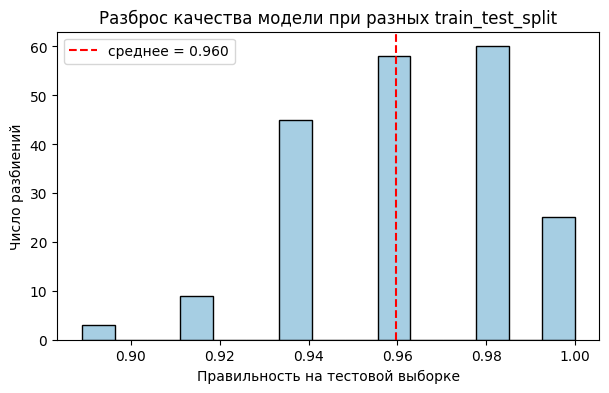

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

iris = load_iris()
single_split_scores = []
for seed in range(200):
    X_train, X_test, y_train, y_test = train_test_split(
        iris.data, iris.target, test_size=0.3, random_state=seed)
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    single_split_scores.append(model.score(X_test, y_test))

single_split_scores = np.array(single_split_scores)
print("Правильность (одно разбиение), min/mean/max: {:.3f} / {:.3f} / {:.3f}".format(
    single_split_scores.min(), single_split_scores.mean(), single_split_scores.max()))
print("Стандартное отклонение: {:.3f}".format(single_split_scores.std()))

plt.figure(figsize=(7, 4))
plt.hist(single_split_scores, bins=15, color="#a6cee3", edgecolor="black")
plt.axvline(single_split_scores.mean(), color="red", linestyle="--",
            label="среднее = {:.3f}".format(single_split_scores.mean()))
plt.xlabel("Правильность на тестовой выборке")
plt.ylabel("Число разбиений")
plt.title("Разброс качества модели при разных train_test_split")
plt.legend()
plt.show()

Видно, что в зависимости от `random_state` правильность заметно
«гуляет». Один-единственный `train_test_split` — это, по сути, одно
случайное наблюдение из целого распределения возможных оценок
качества, и полагаться на него рискованно, особенно когда:

* данных немного, и один «неудачный» тестовый набор сильно искажает
  оценку;
* мы сравниваем несколько моделей или подбираем гиперпараметры и
  выбираем «лучшую» — легко выбрать модель, которая просто удачно
  легла на конкретный тестовый набор (переобучение на тестовой
  выборке / data leakage);
* нужно понимать не только среднее качество, но и его **разброс**
  (насколько стабильно ведёт себя модель).

**Кросс-валидация (перекрёстная проверка)** решает эти проблемы: данные
разбиваются на несколько частей (блоков, folds), и по очереди каждая
часть побывает тестовой, а модель обучается заново на оставшихся
данных. В итоге вместо одного числа мы получаем *несколько* оценок
качества, по которым можно посчитать среднее и разброс (std).

Самый распространённый вариант — **k-блочная кросс-проверка
(k-fold cross-validation)**: данные делятся на *k* примерно равных
блоков (обычно k=5 или k=10), и модель обучается и тестируется *k* раз,
каждый раз с новым блоком в роли тестового.

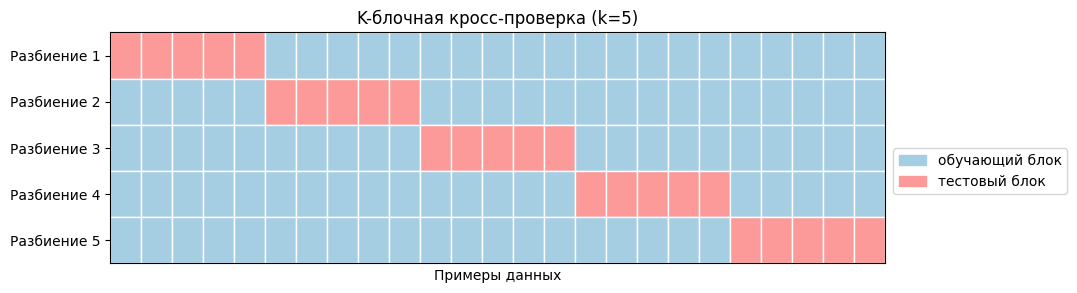

In [3]:
mglearn.plots.plot_cross_validation(n_splits=5)
plt.show()

In [4]:
from sklearn.model_selection import cross_val_score

logreg = LogisticRegression(max_iter=1000)
scores = cross_val_score(logreg, iris.data, iris.target, cv=5)
print("Оценки правильности по 5 блокам:", np.round(scores, 3))
print("Средняя правильность: {:.3f}".format(scores.mean()))
print("Стандартное отклонение: {:.3f}".format(scores.std()))

Оценки правильности по 5 блокам: [0.967 1.    0.933 0.967 1.   ]
Средняя правильность: 0.973
Стандартное отклонение: 0.025


### Зачем именно нужна кросс-валидация — коротко по пунктам

1. **Более надёжная и устойчивая оценка качества.** Усреднение по
   нескольким разным разбиениям снижает дисперсию оценки — на неё
   меньше влияет "везение" или "невезение" одного конкретного
   разбиения (см. эксперимент выше: `std` по k-fold обычно заметно
   меньше, чем разброс отдельных `train_test_split`).
2. **Эффективное использование данных.** При k-fold CV каждый пример
   побывает и в обучающей, и в тестовой выборке (ровно один раз — в
   тестовой). Это особенно важно на небольших датасетах, где жалко
   "терять" данные на постоянный тестовый набор.
3. **Оценка разброса (стабильности) качества модели**, а не только
   единственного числа: значение `scores.std()` показывает, насколько
   сильно качество модели зависит от конкретного разбиения данных —
   это тоже важная характеристика модели.
4. **Честный подбор гиперпараметров.** Если для выбора гиперпараметров
   многократно смотреть на один и тот же тестовый набор, происходит
   неявная "утечка" информации о нём в процесс выбора модели, и
   итоговая оценка качества становится слишком оптимистичной.
   Кросс-валидация на *обучающей* части данных позволяет подбирать
   гиперпараметры, ни разу не заглядывая в тестовую выборку (о этом
   подробнее — в разделе 3).
5. **Возможность выявить проблемы с данными**, например, слишком
   сильную зависимость модели от конкретных примеров, или ситуацию,
   когда сортировка/группировка данных приводит к тому, что в одном
   из блоков отсутствует целый класс (см. далее про `StratifiedKFold`
   и `GroupKFold`).

Важно понимать: кросс-валидация — это **не способ построить одну
"лучшую" модель**. Как метод она возвращает несколько временных
моделей, обученных внутри процедуры, но они, как правило,
выбрасываются, а на выходе остаётся не сама модель, а более надёжная
**оценка её качества** (и, по итогам, — финальная модель обучается
заново уже на всех данных).

## 2. Виды кросс-валидации в scikit-learn

Все "разбивалки" (splitters) в scikit-learn имеют единый интерфейс:
метод `.split(X, y, groups)`, который возвращает индексы `train`/`test`
для каждой итерации. Это позволяет использовать их взаимозаменяемо —
в том числе передавая параметр `cv=` в `cross_val_score`,
`cross_validate`, `GridSearchCV` и т.д.

### 2.1 `KFold`

Базовый вариант: данные делятся на `n_splits` последовательных блоков.

**Параметры:** `n_splits` (число блоков, по умолчанию 5), `shuffle`
(перемешивать ли данные перед разбиением на блоки, по умолчанию
`False`), `random_state` (фиксирует перемешивание, если `shuffle=True`).

**Плюсы:**
* прост и понятен, "эталонная" схема кросс-валидации;
* каждый пример ровно один раз оказывается в тестовом блоке;
* подходит и для классификации, и для регрессии.

**Минусы (ограничения):**
* если `shuffle=False` (по умолчанию!) и данные упорядочены — например,
  отсортированы по классам, как часто бывает в учебных датасетах —
  блоки могут оказаться сильно несбалансированными по классам, вплоть
  до полного отсутствия класса в блоке;
* не учитывает структуру данных (группы, временной порядок и т.д.).

Ниже — наглядная демонстрация проблемы: `iris` отсортирован по классам,
поэтому `KFold(shuffle=False)` на нём "ломается".

In [5]:
from sklearn.model_selection import KFold

print("Классы в iris.target идут по порядку:", np.unique(iris.target, return_counts=True))

logreg = LogisticRegression(max_iter=1000)

kfold_no_shuffle = KFold(n_splits=3)  # shuffle=False по умолчанию!
scores_bad = cross_val_score(logreg, iris.data, iris.target, cv=kfold_no_shuffle)
print("KFold(shuffle=False), 3 блока:", scores_bad)

kfold_shuffle = KFold(n_splits=3, shuffle=True, random_state=0)
scores_good = cross_val_score(logreg, iris.data, iris.target, cv=kfold_shuffle)
print("KFold(shuffle=True), 3 блока: ", np.round(scores_good, 3))

Классы в iris.target идут по порядку: (array([0, 1, 2]), array([50, 50, 50]))
KFold(shuffle=False), 3 блока: [0. 0. 0.]
KFold(shuffle=True), 3 блока:  [0.98 0.96 0.96]


Видно, что без перемешивания правильность на каждом блоке равна
**0**: каждый блок целиком состоит из одного класса, которого модель
никогда не видела на обучении. Перемешивание (`shuffle=True`) решает
проблему — но всё равно не гарантирует одинаковое соотношение классов
в каждом блоке. Для этого нужен `StratifiedKFold`.

### 2.2 `StratifiedKFold`

Стратифицированный вариант k-блочной проверки: блоки формируются так,
чтобы в каждом сохранялась (примерно) исходная пропорция классов.

**Параметры:** `n_splits`, `shuffle`, `random_state` — те же, что и у
`KFold`.

**Плюсы:**
* сохраняет пропорции классов в каждом блоке — даёт более надёжную и
  менее шумную оценку для классификации, особенно при небольшом числе
  примеров или несбалансированных классах;
* в scikit-learn используется **по умолчанию**, когда `cv` задаётся
  просто числом (`cv=5`) и оценивается классификатор.

**Минусы (ограничения):**
* неприменим "как есть" к регрессии (нет дискретных классов для
  стратификации — хотя существуют обходные пути через биннинг целевой
  переменной);
* если какого-то класса меньше, чем `n_splits`, стратификация
  невозможна (будет ошибка);
* как и `KFold`, не учитывает группы/временной порядок.

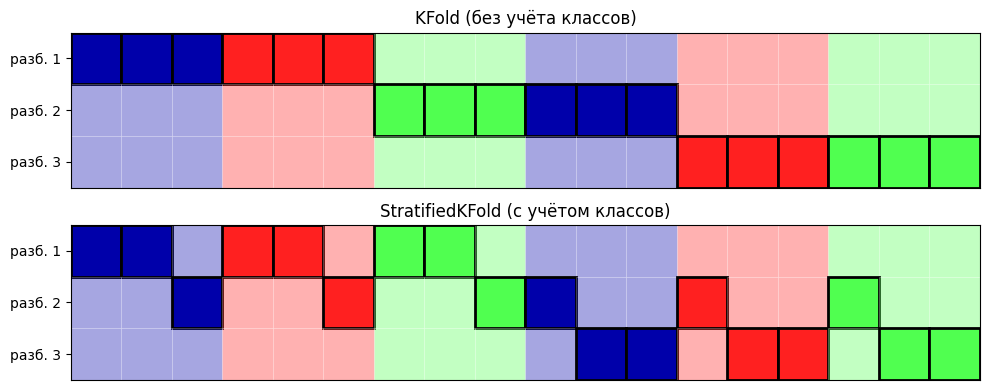

In [6]:
mglearn.plots.plot_stratified_cross_validation()
plt.show()

In [7]:
from sklearn.model_selection import StratifiedKFold

skfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
scores_strat = cross_val_score(logreg, iris.data, iris.target, cv=skfold)
print("StratifiedKFold, 3 блока:", np.round(scores_strat, 3))
print("Среднее: {:.3f}, std: {:.3f}".format(scores_strat.mean(), scores_strat.std()))

StratifiedKFold, 3 блока: [0.96 0.98 0.94]
Среднее: 0.960, std: 0.016


### 2.3 `LeaveOneOut` (LOO) и `LeavePOut`

`LeaveOneOut` — предельный случай k-блочной проверки, когда
`n_splits == n_samples`: на каждой итерации тестовым является ровно
**один** пример, а все остальные — обучающими.

**Параметры:** у `LeaveOneOut` параметров нет — число разбиений всегда
равно числу примеров. У `LeavePOut` есть параметр `p` — число объектов,
оставляемых в тестовую выборку на каждой итерации (перебираются все
возможные сочетания из `p` объектов).

**Плюсы:**
* максимальное использование обучающих данных на каждой итерации (в
  обучении участвуют `n-1` примеров) — полезно для очень маленьких
  датасетов;
* никакой случайности — результат детерминирован (в отличие от
  ShuffleSplit).

**Минусы (ограничения):**
* очень требователен к вычислениям: нужно обучить модель `n` раз (для
  `LeavePOut` — `C(n, p)` раз, что быстро становится астрономическим
  числом);
* оценка качества на каждой итерации по одному примеру — очень
  "шумная" метрика (accuracy на 1 объекте — это либо 0, либо 1);
  в сумме такая CV может давать *высокую дисперсию* итоговой оценки,
  несмотря на низкое смещение (bias);
* плохо подходит для больших датасетов.

In [8]:
from sklearn.model_selection import LeaveOneOut

# для скорости берём укороченную версию iris (по 10 примеров каждого класса)
_, X_small, _, y_small = train_test_split(
    iris.data, iris.target, test_size=30, stratify=iris.target, random_state=0)

loo = LeaveOneOut()
scores_loo = cross_val_score(logreg, X_small, y_small, cv=loo)
print("Число разбиений LeaveOneOut:", len(scores_loo))
print("Средняя правильность: {:.3f}".format(scores_loo.mean()))
print("Пример значений (первые 10):", scores_loo[:10])

Число разбиений LeaveOneOut: 30
Средняя правильность: 1.000
Пример значений (первые 10): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 2.4 `ShuffleSplit` и `StratifiedShuffleSplit`

На каждой итерации случайным образом выбираются `train_size` объектов
в обучающую выборку и `test_size` — в тестовую (независимо от
предыдущих итераций); часть объектов может не попасть ни в одну из
выборок, а часть — попасть в тестовую выборку несколько раз за разные
итерации.

**Параметры:** `n_splits` (число итераций), `train_size`, `test_size`
(доли либо абсолютные числа), `random_state`.
`StratifiedShuffleSplit` — то же самое, но с сохранением пропорций
классов (аналог `StratifiedKFold` для `ShuffleSplit`).

**Плюсы:**
* число итераций (`n_splits`) отвязано от размера train/test — можно
  сделать хоть 100 итераций с небольшой тестовой выборкой, что
  невозможно в KFold;
* удобно "подсэмплировать" большие датасеты (задать `train_size`
  меньше 100% данных) для ускорения экспериментов;
* гибкий контроль над соотношением train/test.

**Минусы (ограничения):**
* нет гарантии, что каждый объект попадёт в тестовую выборку хотя бы
  один раз (в отличие от KFold) — часть данных может вообще не
  использоваться для проверки;
* некоторые объекты тестируются чаще других — оценка может быть
  смещена в их сторону;
* (для базового `ShuffleSplit`) не учитывает баланс классов — для
  классификации обычно предпочтительнее `StratifiedShuffleSplit`.

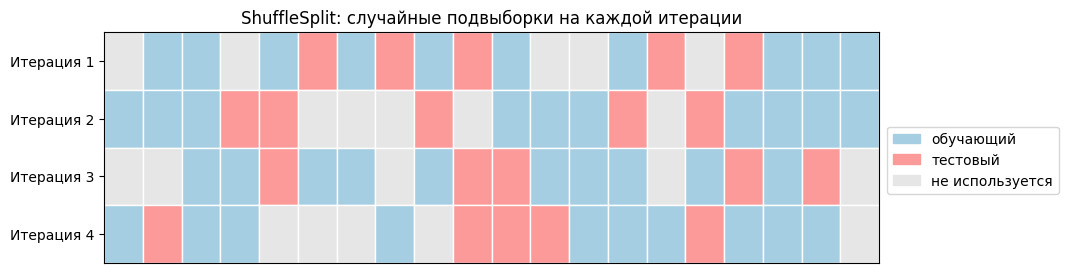

In [9]:
mglearn.plots.plot_shuffle_split()
plt.show()

In [10]:
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit

shuffle_split = ShuffleSplit(n_splits=10, train_size=0.7, test_size=0.3, random_state=0)
scores_ss = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)
print("ShuffleSplit, 10 итераций:", np.round(scores_ss, 3))

strat_shuffle_split = StratifiedShuffleSplit(n_splits=10, train_size=0.7,
                                              test_size=0.3, random_state=0)
scores_sss = cross_val_score(logreg, iris.data, iris.target, cv=strat_shuffle_split)
print("StratifiedShuffleSplit, 10 итераций:", np.round(scores_sss, 3))

ShuffleSplit, 10 итераций: [0.978 0.933 0.956 0.911 0.978 0.933 1.    1.    1.    0.978]
StratifiedShuffleSplit, 10 итераций: [1.    0.978 0.978 0.978 0.956 0.956 0.978 0.978 0.978 0.956]


### 2.5 `GroupKFold` (и `GroupShuffleSplit`, `LeaveOneGroupOut`)

Используется, когда объекты не независимы друг от друга, а образуют
группы — например, несколько снимков одного пациента, несколько
записей одного пользователя, несколько строк одной компании и т.д.
Если объекты одной группы случайно окажутся и в train, и в test,
модель может просто "запомнить" группу — и оценка качества будет
завышена (это частный случай утечки данных, *data leakage*).
`GroupKFold` гарантирует, что вся группа целиком попадает **либо** в
обучающую, **либо** в тестовую выборку.

**Параметры:** `n_splits`. В `.split(X, y, groups)` дополнительно
передаётся массив `groups` — метка группы для каждого объекта.

**Плюсы:**
* предотвращает утечку данных между train и test через связанные
  объекты — даёт честную оценку обобщающей способности на *новые*
  группы (пациентов, пользователей и т.п.);
* легко встраивается в любой pipeline, где уже используется `cv=`.

**Минусы (ограничения):**
* требует явно заданных меток групп, которые не всегда доступны;
* блоки могут получиться существенно разного размера, если размеры
  групп сильно различаются (алгоритм старается их сбалансировать, но
  не всегда идеально);
* не гарантирует сохранение пропорций классов (нет "стратифицированной"
  версии GroupKFold в стабильном API одновременно с группировкой и
  стратификацией — для этого есть `StratifiedGroupKFold`).

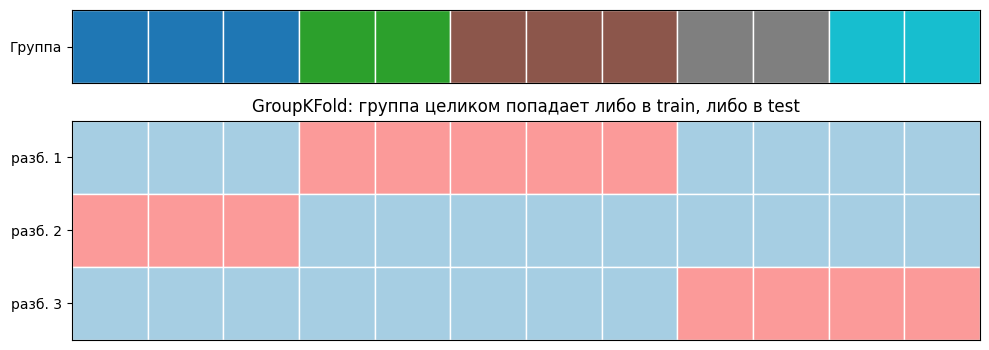

In [11]:
mglearn.plots.plot_group_kfold()
plt.show()

In [12]:
from sklearn.model_selection import GroupKFold
from sklearn.datasets import make_blobs

# синтетические данные: 12 объектов, объединённых в 5 групп
X_g, y_g = make_blobs(n_samples=12, random_state=0)
groups = np.array([0, 0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4])

gkf = GroupKFold(n_splits=3)
for i, (train_idx, test_idx) in enumerate(gkf.split(X_g, y_g, groups=groups)):
    print(f"Разбиение {i}: группы в train = {sorted(set(groups[train_idx]))}, "
          f"группы в test = {sorted(set(groups[test_idx]))}")

scores_gkf = cross_val_score(logreg, X_g, y_g, cv=gkf, groups=groups)
print("Оценки:", np.round(scores_gkf, 3))

Разбиение 0: группы в train = [np.int64(0), np.int64(3), np.int64(4)], группы в test = [np.int64(1), np.int64(2)]
Разбиение 1: группы в train = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)], группы в test = [np.int64(0)]
Разбиение 2: группы в train = [np.int64(0), np.int64(1), np.int64(2)], группы в test = [np.int64(3), np.int64(4)]
Оценки: [0.8   0.667 0.75 ]


### 2.6 `TimeSeriesSplit`

Специальный вариант для **временных рядов**, где нарушать порядок
времени нельзя: тестовые данные всегда идут *после* обучающих по
времени (иначе модель будет "подглядывать в будущее" — look-ahead
bias).

**Параметры:** `n_splits`, `max_train_size` (ограничение на размер
обучающей выборки), `test_size`, `gap` (сколько наблюдений пропустить
между train и test — чтобы избежать утечки через скользящие признаки).

**Плюсы:**
* единственный "честный" способ кросс-валидации для данных с временной
  зависимостью — сохраняет причинно-следственный порядок;
* хорошо соответствует реальному сценарию использования модели
  (прогноз будущего по прошлому).

**Минусы (ограничения):**
* обучающая выборка на разных итерациях имеет разный размер (растёт
  со временем) — оценки на разных блоках менее сопоставимы между собой;
* на первых итерациях обучающих данных может быть мало;
* не подходит, если данные не имеют временной природы (заведомо
  избыточное ограничение).

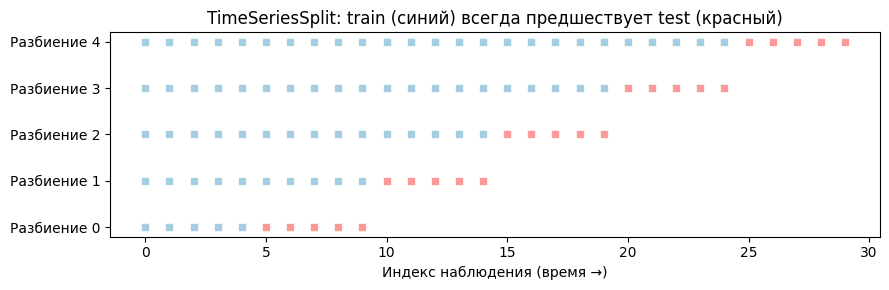

In [13]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
n_points = 30

fig, ax = plt.subplots(figsize=(9, 3))
for i, (train_idx, test_idx) in enumerate(tscv.split(np.arange(n_points))):
    ax.scatter(train_idx, [i] * len(train_idx), color="#a6cee3", marker="s", s=25)
    ax.scatter(test_idx, [i] * len(test_idx), color="#fb9a99", marker="s", s=25)
ax.set_yticks(range(5))
ax.set_yticklabels([f"Разбиение {i}" for i in range(5)])
ax.set_xlabel("Индекс наблюдения (время →)")
ax.set_title("TimeSeriesSplit: train (синий) всегда предшествует test (красный)")
plt.tight_layout()
plt.show()

### 2.7 `RepeatedKFold` / `RepeatedStratifiedKFold`

Повторяет обычный `KFold`/`StratifiedKFold` `n_repeats` раз с разными
случайными перемешиваниями данных и объединяет все полученные оценки.

**Параметры:** `n_splits`, `n_repeats`, `random_state`.

**Плюсы:**
* дополнительно снижает дисперсию итоговой оценки качества (усреднение
  идёт уже не по k, а по `k * n_repeats` значениям);
* особенно полезен на небольших датасетах, где даже единственный
  k-fold даёт заметный разброс между запусками с разными `random_state`.

**Минусы (ограничения):**
* вычислительные затраты растут прямо пропорционально `n_repeats` —
  модель обучается `n_splits * n_repeats` раз;
* отдельные повторы не являются полностью независимыми (используются
  одни и те же данные), поэтому выигрыш в точности оценки — не такой,
  как от сбора нового независимого датасета такого же объёма.

In [14]:
from sklearn.model_selection import RepeatedStratifiedKFold

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=0)
scores_rskf = cross_val_score(logreg, iris.data, iris.target, cv=rskf)
print("RepeatedStratifiedKFold: {} оценок (5 блоков x 4 повтора)".format(len(scores_rskf)))
print("Среднее: {:.3f}, std: {:.3f}".format(scores_rskf.mean(), scores_rskf.std()))

RepeatedStratifiedKFold: 20 оценок (5 блоков x 4 повтора)
Среднее: 0.965, std: 0.036


### 2.8 Функция `cross_validate`

В отличие от `cross_val_score`, которая возвращает только массив
значений одной метрики, `cross_validate` — более гибкая функция,
позволяющая одновременно считать **несколько метрик**, а также
возвращать время обучения/предсказания, сами обученные модели и
оценки на обучающей выборке (для диагностики переобучения).

**Основные параметры:** `estimator`, `X`, `y`, `groups`, `scoring`
(строка, список строк или словарь `{имя: scorer}`), `cv`, `n_jobs`,
`return_train_score` (по умолчанию `False`), `return_estimator`
(вернуть обученные на каждом блоке модели), `error_score`.

**Плюсы:**
* несколько метрик за один проход по данным (не нужно гонять CV
  отдельно под каждую метрику);
* `return_train_score=True` позволяет сравнить качество на train и на
  test и увидеть переобучение;
* `return_estimator=True` даёт доступ к самим обученным на блоках
  моделям (например, для анализа важности признаков на каждом блоке).

**Минусы (ограничения):**
* возвращает словарь, а не просто массив — требуется чуть больше кода
  для распаковки результата;
* по-прежнему не решает задачу подбора гиперпараметров сама по себе —
  для этого нужны `GridSearchCV`/`RandomizedSearchCV` (раздел 3).

In [15]:
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import cross_validate

digits = load_digits()
# бинарная задача: цифра 9 против остальных
res = cross_validate(SVC(gamma="scale"), digits.data, digits.target == 9,
                      scoring=["accuracy", "roc_auc", "recall_macro"],
                      return_train_score=True, cv=5)
display(pd.DataFrame(res))

   fit_time  score_time  test_accuracy  train_accuracy  test_roc_auc  train_roc_auc  test_recall_macro  train_recall_macro
0  0.009555    0.010911       0.975000        0.994433      0.997171       0.998679           0.887346            0.972222
1  0.009236    0.010580       0.991667        0.995825      0.998543       0.999141           0.958333            0.982252
2  0.009334    0.010308       1.000000        0.995132      1.000000       0.998975           1.000000            0.978780
3  0.008998    0.010619       0.994429        0.995828      0.999828       0.998825           0.972222            0.982252
4  0.008912    0.009707       0.980501        0.996523      0.984004       0.999914           0.902778            0.985725


### Сводная таблица по видам кросс-валидации

| Метод | Когда использовать | Основной плюс | Основной минус |
|---|---|---|---|
| `KFold` | базовый случай, регрессия | просто, каждый пример тестируется 1 раз | без `shuffle` чувствителен к порядку данных |
| `StratifiedKFold` | классификация (используется по умолчанию) | сохраняет пропорции классов | не для регрессии "из коробки" |
| `LeaveOneOut` | очень маленькие датасеты | максимум данных на обучение | очень дорого, шумная метрика |
| `LeavePOut` | очень маленькие датасеты, нужна полная комбинаторика | наиболее полная проверка всех сочетаний | комбинаторный взрыв при росте n, p |
| `ShuffleSplit` | нужен контроль над train/test size, subsampling | гибкость числа итераций и размеров | не все объекты обязательно тестируются |
| `StratifiedShuffleSplit` | то же + классификация | + сохраняет пропорции классов | то же |
| `GroupKFold` | связанные объекты (пациенты, пользователи) | не допускает утечки между train/test | нужны метки групп |
| `TimeSeriesSplit` | временные ряды | сохраняет временной порядок | обучающая выборка растёт по размеру |
| `RepeatedKFold` | нужна ещё более стабильная оценка | меньше дисперсии итоговой оценки | дороже по вычислениям |
| `cross_validate` | нужно несколько метрик / доступ к моделям | гибкость вывода | не про подбор гиперпараметров |


## 3. Подбор гиперпараметров

Гиперпараметры (например, `C` и `gamma` у `SVC`, глубина дерева,
число соседей у kNN) нельзя подобрать через `fit` — их нужно задавать
заранее и выбирать по качеству модели на данных, которые не
участвовали в обучении. Разберём несколько подходов — от наивного до
более продвинутых.

### 3.1 Наивный перебор (без кросс-валидации)

Самый простой (и самый ошибочный, если делать в лоб) вариант: для
каждой комбинации гиперпараметров обучить модель на train и
сразу оценить на test, выбрав комбинацию с лучшим результатом на test.

**Проблема:** тестовая выборка при этом используется многократно —
для *выбора* модели, а не только для её итоговой оценки. В результате
финальная оценка качества на test оказывается слишком оптимистичной:
мы, по сути, подобрали гиперпараметры "под" эту конкретную тестовую
выборку (утечка информации, аналог переобучения, но на этапе выбора
модели, а не обучения весов).

In [16]:
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0)

best_score = 0
best_params = {}
for gamma in [0.001, 0.01, 0.1, 1, 10]:
    for C in [0.001, 0.01, 0.1, 1, 10]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        score = svm.score(X_test, y_test)   # !!! оцениваем на тестовой выборке
        if score > best_score:
            best_score = score
            best_params = {"C": C, "gamma": gamma}

print("Наивный перебор — лучший результат на test: {:.3f}".format(best_score))
print("Лучшие параметры:", best_params)
print("ВНИМАНИЕ: это оптимистично смещённая оценка — test использовался для выбора C, gamma")

Наивный перебор — лучший результат на test: 0.974
Лучшие параметры: {'C': 10, 'gamma': 0.01}
ВНИМАНИЕ: это оптимистично смещённая оценка — test использовался для выбора C, gamma


Правильный подход — использовать для подбора гиперпараметров
**отдельную** от финального теста выборку: либо явную
валидационную выборку (трёхстороннее разбиение train/validation/test),
либо (что надёжнее и экономнее по данным) — кросс-валидацию внутри
обучающей выборки.

### 3.2 Решётчатый поиск с перекрёстной проверкой (`GridSearchCV`)

Идея: полностью перебрать все комбинации значений гиперпараметров
из заданной "решётки" (`param_grid`), но для оценки качества *каждой*
комбинации использовать не один validation-сплит, а полноценную
кросс-валидацию на обучающей выборке. Тестовая выборка при этом
остаётся полностью "нетронутой" до самого конца и используется только
один раз — для финальной, честной оценки уже выбранной модели.

**Параметры `GridSearchCV`:** `estimator`, `param_grid` (словарь или
список словарей "имя параметра → список значений"), `scoring`, `cv`,
`n_jobs`, `refit` (переобучить ли лучшую модель на всей обучающей
выборке, по умолчанию `True`), `return_train_score`, `verbose`.

**Плюсы:**
* гарантированно находит лучшую комбинацию *в пределах заданной
  решётки* — исчерпывающий перебор;
* качество каждой комбинации оценивается по кросс-валидации, а не по
  одному разбиению — оценка устойчивее;
* после `fit` доступны `best_params_`, `best_score_`, `best_estimator_`,
  подробная таблица `cv_results_`.

**Минусы (ограничения):**
* **комбинаторный взрыв**: время работы растёт экспоненциально с
  числом гиперпараметров и линейно с плотностью решётки по каждому —
  для многомерных пространств становится практически неприменим;
* решётка задаётся вручную — если диапазон значений выбран неудачно
  (слишком узко/широко/грубо), можно пропустить хороший регион;
* при большом числе комбинаций и маленьком `cv` есть риск
  переобучиться уже *на кросс-валидационные блоки* (validation set
  overfitting) — для честной финальной оценки качества в этом случае
  стоит использовать вложенную кросс-валидацию (см. 3.5).

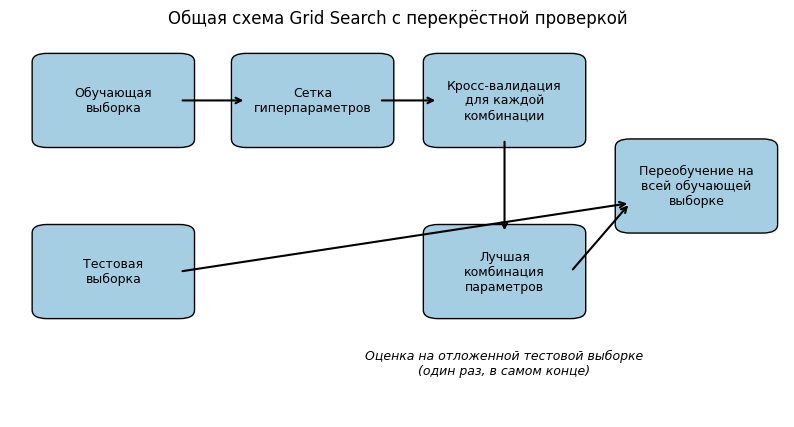

In [17]:
mglearn.plots.plot_grid_search_overview()
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100],
              "gamma": [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(SVC(), param_grid=param_grid, cv=5, return_train_score=True)
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая cv-правильность: {:.3f}".format(grid_search.best_score_))
print("Правильность на тестовой выборке: {:.3f}".format(grid_search.score(X_test, y_test)))

Лучшие параметры: {'C': 10, 'gamma': 0.1}
Лучшая cv-правильность: 0.973
Правильность на тестовой выборке: 0.974


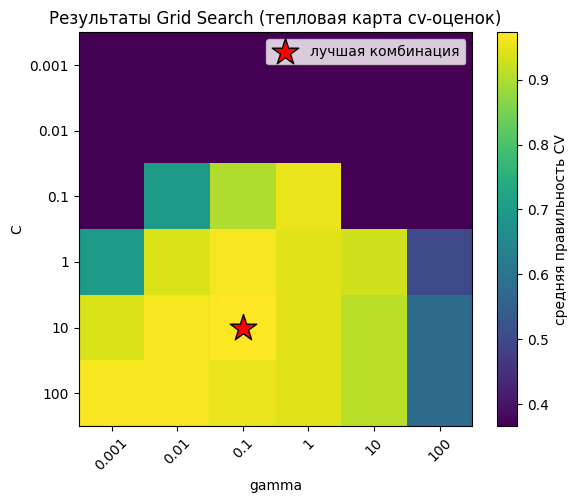

In [19]:
results = pd.DataFrame(grid_search.cv_results_)
scores_grid = np.array(results.mean_test_score).reshape(6, 6)

c_values = param_grid["C"]
gamma_values = param_grid["gamma"]
best_flat_idx = np.argmax(scores_grid)
best_idx = np.unravel_index(best_flat_idx, scores_grid.shape)

mglearn.plots.plot_cross_val_selection(scores_grid, "C", c_values, "gamma", gamma_values,
                                        best_idx=best_idx)
plt.show()

### 3.3 Случайный поиск (`RandomizedSearchCV`)

Вместо полного перебора решётки, на каждой итерации случайным образом
сэмплируется `n_iter` комбинаций гиперпараметров — либо из списков
значений, либо из статистических распределений (`scipy.stats`),
что позволяет задавать непрерывные диапазоны, а не дискретную сетку.

**Параметры:** `estimator`, `param_distributions` (словарь "имя
параметра → список значений или распределение с методом `.rvs()`"),
`n_iter` (число случайных комбинаций), `scoring`, `cv`, `random_state`,
`n_jobs`.

**Плюсы:**
* существенно быстрее исчерпывающего перебора при большом числе
  гиперпараметров — вычислительный бюджет (`n_iter`) задаётся
  напрямую, независимо от размерности пространства;
* по результатам эмпирических исследований (Bergstra & Bengio, 2012),
  при большом числе гиперпараметров случайный поиск часто находит
  сопоставимое по качеству решение за то же время, что и решётчатый —
  потому что не тратит бюджет на равномерный перебор *неважных*
  параметров;
* позволяет задавать непрерывные распределения (например,
  логарифмически равномерное для `C`/`gamma`), а не только
  фиксированный дискретный список значений.

**Минусы (ограничения):**
* не исчерпывающий — не гарантирует нахождение оптимума даже в
  пределах заданных диапазонов, результат зависит от `random_state`;
* нужно заранее выбрать `n_iter` — при слишком малом значении можно
  не успеть обследовать пространство;
* для дискретных/категориальных параметров с малым числом значений
  выгода по сравнению с Grid Search обычно меньше.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_distributions = {"C": loguniform(1e-3, 1e2), "gamma": loguniform(1e-3, 1e2)}

random_search = RandomizedSearchCV(SVC(), param_distributions=param_distributions,
                                    n_iter=25, cv=5, random_state=0)
random_search.fit(X_train, y_train)

print("Лучшие параметры:", random_search.best_params_)
print("Лучшая cv-правильность: {:.3f}".format(random_search.best_score_))
print("Правильность на тестовой выборке: {:.3f}".format(random_search.score(X_test, y_test)))
print("Число обученных комбинаций: {} (вместо {} у полной решётки 6x6)".format(
    len(random_search.cv_results_["params"]), 36))

Лучшие параметры: {'C': np.float64(9.091283280651457), 'gamma': np.float64(0.44103656679709863)}
Лучшая cv-правильность: 0.973
Правильность на тестовой выборке: 0.974
Число обученных комбинаций: 25 (вместо 36 у полной решётки 6x6)


### 3.4 Successive Halving (`HalvingGridSearchCV` / `HalvingRandomSearchCV`)

Более "продвинутый" вариант перебора: поиск начинается с большого
числа кандидатов (комбинаций гиперпараметров), которые оцениваются на
*небольшом* подмножестве обучающих данных (или с небольшим числом
итераций/деревьев и т.п.); затем худшая половина кандидатов
отбрасывается, а оставшиеся оцениваются уже на большем объёме
ресурсов. Процесс повторяется, пока не останется несколько лучших
кандидатов, оценённых на полном датасете.

**Параметры (основные):** `estimator`, `param_grid`/`param_distributions`,
`factor` (во сколько раз сокращается число кандидатов и увеличивается
объём ресурсов на каждой итерации, по умолчанию 3), `resource`
(что наращивается — обычно `"n_samples"`), `min_resources`,
`cv`.

**Плюсы:**
* существенно быстрее полного Grid/Randomized Search при большом числе
  кандидатов — заведомо слабые комбинации отсеиваются рано, не тратя
  вычисления на их полную оценку;
* хорошо сочетается и с решётчатым, и со случайным поиском (есть обе
  вариации).

**Минусы (ограничения):**
* по состоянию на многие версии scikit-learn API остаётся
  экспериментальным (требует `from sklearn.experimental import
  enable_halving_search_cv`) и может меняться;
* оценка на малом подмножестве данных на ранних итерациях — более
  шумная, из-за чего действительно хорошая комбинация может быть
  отброшена слишком рано просто "не повезло" на маленькой подвыборке;
* не для всех моделей ресурс "число примеров" одинаково хорошо
  коррелирует с качеством на полном датасете.

In [21]:
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV

halving_search = HalvingGridSearchCV(SVC(), param_grid=param_grid, cv=5,
                                      factor=3, random_state=0)
halving_search.fit(X_train, y_train)

print("Лучшие параметры:", halving_search.best_params_)
print("Лучшая cv-правильность: {:.3f}".format(halving_search.best_score_))
print("Правильность на тестовой выборке: {:.3f}".format(halving_search.score(X_test, y_test)))
print("Число итераций halving:", halving_search.n_iterations_)

Лучшие параметры: {'C': 1, 'gamma': 0.1}
Лучшая cv-правильность: 0.954
Правильность на тестовой выборке: 0.974
Число итераций halving: 2


### 3.5 Вложенная кросс-валидация (nested cross-validation)

Если использовать один и тот же `cv` и для подбора гиперпараметров, и
для финальной оценки качества (`grid_search.best_score_`), эта оценка
может быть немного оптимистично смещена — ведь мы выбрали лучшую
комбинацию именно по этим блокам. Чтобы получить полностью честную,
не смещённую оценку обобщающей способности **всего процесса**
"подбор гиперпараметров + обучение", используют вложенную (nested)
кросс-валидацию: внешний цикл CV оценивает качество, а внутри каждого
внешнего блока запускается свой независимый `GridSearchCV` (внутренний
цикл CV) только на данных внешнего train.

**Плюсы:**
* даёт несмещённую оценку качества всего пайплайна выбора модели,
  пригодную, например, для честного сравнения нескольких алгоритмов
  между собой;
* явно показывает разброс итогового качества (можно посчитать std по
  внешним блокам).

**Минусы (ограничения):**
* дорого: если внешний cv — 5 блоков, а внутренний Grid Search
  перебирает 36 комбинаций с cv=5, модель обучается `5 * 36 * 5 = 900`
  раз;
* на выходе получаем **оценку качества метода**, а не единый набор
  гиперпараметров для последующего использования в продакшене — для
  этого отдельно запускают `GridSearchCV` уже на всех данных.

In [22]:
from sklearn.model_selection import cross_val_score as cvs

inner_cv = GridSearchCV(SVC(), param_grid=param_grid, cv=5)
nested_scores = cvs(inner_cv, iris.data, iris.target, cv=5)

print("Оценки вложенной CV по внешним блокам:", np.round(nested_scores, 3))
print("Среднее (несмещённая оценка): {:.3f} +- {:.3f}".format(
    nested_scores.mean(), nested_scores.std()))

Оценки вложенной CV по внешним блокам: [0.967 1.    0.967 0.967 1.   ]
Среднее (несмещённая оценка): 0.980 +- 0.016


## 4. Как проверить, репрезентативна ли выборка

Кросс-валидация и подбор гиперпараметров опираются на важное
предположение: обучающая и тестовая (или обучающая и "боевая",
production) выборки взяты из **одного и того же распределения**. Если
это не так — например, тестовые данные собраны в другое время, из
другого источника, после изменения бизнес-процесса — то даже самая
аккуратная кросс-валидация не спасёт от того, что модель на новых
данных будет работать хуже, чем показывает валидация.

**Идея проверки (adversarial validation):**

1. Помечаем все объекты `train` меткой `0`, все объекты `test` —
   меткой `1`.
2. Объединяем оба набора в один датасет (используя только признаки, **без**
   целевой переменной).
3. Обучаем классификатор, задача которого — отличить, откуда пришёл
   объект: из `train` или из `test`. Качество классификатора оцениваем
   с помощью кросс-валидации по метрике ROC AUC.
4. Интерпретация:
   * Если классификатору **не удаётся** уверенно отличить train от
     test (AUC ≈ 0.5, как случайное угадывание) — значит, по
     распределению признаков они неразличимы, и выборка
     **репрезентативна**.
   * Если классификатор **легко** отличает train от test (AUC близко
     к 1.0) — значит, распределения признаков заметно отличаются
     (data drift, разные источники данных и т.п.), и выборка
     **нерепрезентативна**. При этом `feature_importances_` такого
     классификатора подсказывают, *какие именно* признаки сильнее
     всего "выдают" происхождение объекта — с них и стоит начинать
     разбор проблемы.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


def is_representative_sample(X_train, X_test, model=None, cv=5,
                              threshold=0.6, random_state=42, verbose=True):
    '''Проверяет, репрезентативна ли выборка train относительно test
    с помощью adversarial validation.

    Помечает объекты train меткой 0, а объекты test — меткой 1, и
    обучает классификатор отличать одни от других с помощью
    кросс-валидации (метрика ROC AUC). Если классификатор не может
    уверенно отличить train от test (AUC близко к 0.5), их
    распределения похожи — выборка репрезентативна. Если AUC высокий,
    распределения различаются (data drift) — выборка не репрезентативна.

    Параметры
    ----------
    X_train, X_test : array-like, shape (n, n_features)
        Матрицы признаков (без целевой переменной).
    model : sklearn-совместимый классификатор или None
        Модель для adversarial validation. По умолчанию
        RandomForestClassifier.
    cv : int
        Число блоков стратифицированной кросс-валидации.
    threshold : float
        Порог AUC: если средний AUC >= threshold, выборка считается
        нерепрезентативной.
    random_state : int
        Фиксирует случайность модели и разбиения.
    verbose : bool
        Печатать ли текстовый отчёт.

    Возвращает
    ----------
    dict с ключами:
        'auc' - средний ROC AUC по кросс-валидации,
        'fold_scores' - оценки AUC по каждому блоку,
        'is_representative' - bool,
        'feature_importances' - важности признаков (если модель их поддерживает)
    '''
    X_train = np.asarray(X_train)
    X_test = np.asarray(X_test)
    X_combined = np.vstack([X_train, X_test])
    y_combined = np.concatenate([np.zeros(len(X_train)), np.ones(len(X_test))])

    if model is None:
        model = RandomForestClassifier(n_estimators=300, max_depth=6,
                                        random_state=random_state, n_jobs=-1)

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    fold_scores = cross_val_score(model, X_combined, y_combined,
                                   cv=skf, scoring="roc_auc")
    mean_auc = fold_scores.mean()
    is_repr = mean_auc < threshold

    result = {"auc": mean_auc, "fold_scores": fold_scores,
              "is_representative": is_repr}

    if hasattr(model, "feature_importances_") or hasattr(model, "fit"):
        fitted = model.fit(X_combined, y_combined)
        if hasattr(fitted, "feature_importances_"):
            result["feature_importances"] = fitted.feature_importances_

    if verbose:
        verdict = "РЕПРЕЗЕНТАТИВНА" if is_repr else "НЕ репрезентативна"
        print("Adversarial validation ROC AUC: {:.3f} (+- {:.3f})".format(
            mean_auc, fold_scores.std()))
        print("Порог: {:.2f}  ->  Выборка: {}".format(threshold, verdict))
        if not is_repr:
            print("Классификатор уверенно отличает train от test — "
                  "распределения признаков различаются (возможен data drift).")
        else:
            print("Классификатор не может уверенно отличить train от test — "
                  "распределения признаков похожи.")
    return result

**Сценарий A — репрезентативная выборка.** Обычный случайный
`train_test_split` на одном и том же датасете: train и test взяты из
одного распределения.

In [24]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(data.data, data.target,
                                           test_size=0.3, random_state=0)

result_a = is_representative_sample(X_tr, X_te)

Adversarial validation ROC AUC: 0.476 (+- 0.062)
Порог: 0.60  ->  Выборка: РЕПРЕЗЕНТАТИВНА
Классификатор не может уверенно отличить train от test — распределения признаков похожи.


**Сценарий B — нерепрезентативная выборка.** Искусственно создадим
сдвиг распределения (covariate shift): отсортируем данные по одному из
признаков и возьмём как train — объекты с "маленькими" значениями
этого признака, а как test — с "большими". Это имитирует, например,
ситуацию, когда тестовые данные собраны позже и параметры процесса
измерения сместились.

Adversarial validation ROC AUC: 1.000 (+- 0.000)
Порог: 0.60  ->  Выборка: НЕ репрезентативна
Классификатор уверенно отличает train от test — распределения признаков различаются (возможен data drift).


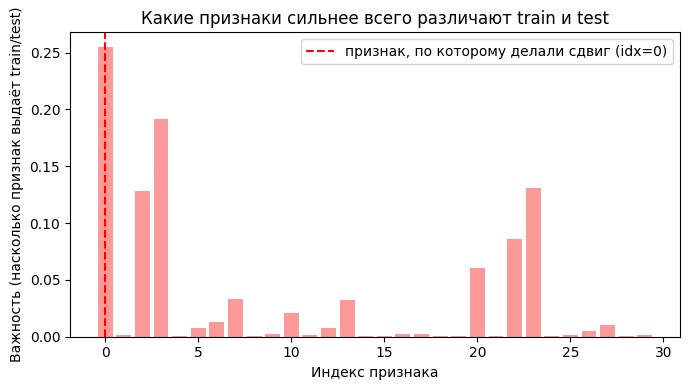

In [25]:
feature_idx = 0  # 'mean radius'
order = np.argsort(data.data[:, feature_idx])
split_point = int(0.7 * len(order))
train_idx, test_idx = order[:split_point], order[split_point:]

X_tr_shift, X_te_shift = data.data[train_idx], data.data[test_idx]

result_b = is_representative_sample(X_tr_shift, X_te_shift)

plt.figure(figsize=(7, 4))
plt.bar(range(len(result_b["feature_importances"])), result_b["feature_importances"],
        color="#fb9a99")
plt.xlabel("Индекс признака")
plt.ylabel("Важность (насколько признак выдаёт train/test)")
plt.title("Какие признаки сильнее всего различают train и test")
plt.axvline(feature_idx, color="red", linestyle="--",
            label=f"признак, по которому делали сдвиг (idx={feature_idx})")
plt.legend()
plt.tight_layout()
plt.show()

Как и ожидалось: во втором сценарии AUC близок к 1.0 (модель
легко отличает train от test), а самым "важным" признаком для этого
разделения оказывается именно тот, по которому мы искусственно
сортировали данные — то есть функция корректно "поймала" источник
нерепрезентативности.

## 5. Coarse-to-fine search («грубо, затем точно»)

**Coarse-to-fine search** — эвристическая двухэтапная стратегия
подбора гиперпараметров, популярная, в частности, в обучении глубоких
сетей (упоминается, например, в курсе Andrew Ng по deep learning):

1. **Coarse-этап (грубый).** Сначала выполняется **случайный поиск**
   (`RandomizedSearchCV`-подобный) по широкому диапазону значений
   каждого гиперпараметра — часто на логарифмической шкале (например,
   learning rate от `1e-5` до `1`). Цель — не найти точный оптимум, а
   грубо понять, *в каком порядке величин* лежат хорошие значения, и
   выявить перспективный регион пространства гиперпараметров.
2. **Fine-этап (точный).** Вокруг лучшей найденной на первом этапе
   точки строится **узкая локальная сетка** (grid) с более мелким
   шагом, и по ней выполняется уже исчерпывающий решётчатый поиск —
   чтобы уточнить значения гиперпараметров внутри перспективного
   региона.

**Плюсы:**
* значительно дешевле по вычислениям, чем плотная решётка по всему
  (широкому) диапазону значений — мелкий шаг применяется только там,
  где он действительно нужен;
* сочетает сильные стороны обоих подходов: широкий охват пространства
  случайным поиском на этапе разведки + исчерпывающую точность
  решётчатого поиска на этапе уточнения;
* хорошо работает, когда диапазоны значений гиперпараметров заранее
  неизвестны и могут отличаться на порядки (learning rate, C, gamma).

**Минусы (ограничения):**
* эвристика без теоретических гарантий оптимальности: если
  coarse-этап "не заметил" истинно лучший регион (слишком мало
  случайных точек, "рваная"/многомодальная поверхность качества),
  fine-этап будет уточнять заведомо неоптимальную область;
* появляются новые гиперпараметры *самого поиска* — сколько точек
  сэмплировать на coarse-этапе, насколько широка "окрестность" для
  fine-этапа, — которые тоже нужно выбирать;
* для действительно дорогих и многомерных задач более совершенной
  альтернативой считаются адаптивные методы, например, байесовская
  оптимизация, которая учитывает результаты *всех* предыдущих
  запусков, а не только двух фиксированных этапов.

Проиллюстрируем идею на плоскости `(C, gamma)`: слева — редкие
случайные точки по всему широкому диапазону (coarse), справа — плотная
сетка в узкой окрестности лучшей найденной точки (fine).

Лучшая точка после coarse-этапа:  C=2.667, gamma=2.707, score=0.956
Лучшая точка после fine-этапа:    C=0.67, gamma=0.68, score=0.973


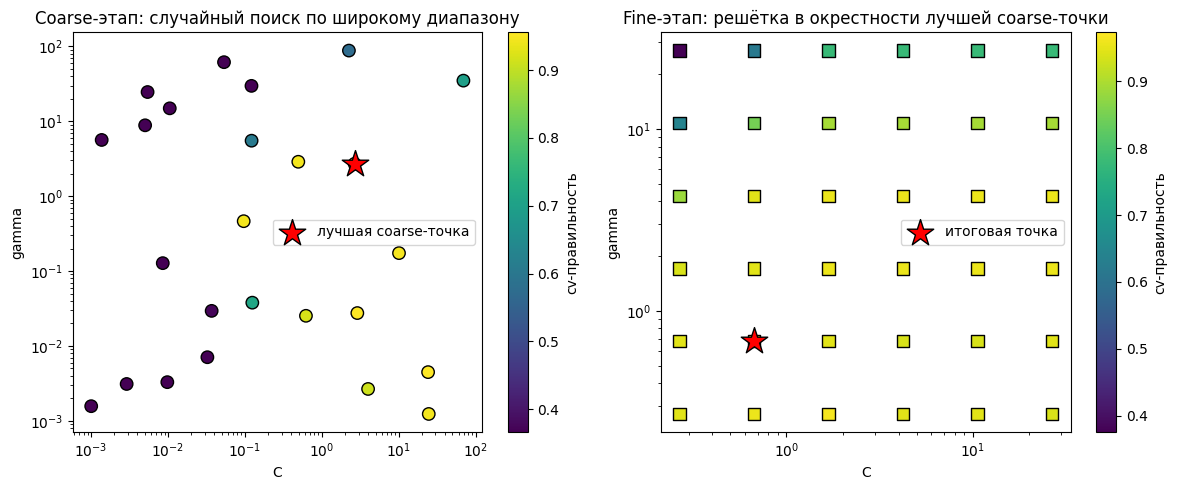

In [26]:
from sklearn.model_selection import cross_val_score as _cvs

def _quality(C, gamma):
    return cross_val_score(SVC(C=C, gamma=gamma), X_train, y_train, cv=3).mean()

rng = np.random.RandomState(1)
n_coarse = 25
coarse_C = 10 ** rng.uniform(-3, 2, n_coarse)
coarse_gamma = 10 ** rng.uniform(-3, 2, n_coarse)
coarse_scores = np.array([_quality(c, g) for c, g in zip(coarse_C, coarse_gamma)])

best_i = np.argmax(coarse_scores)
best_C, best_gamma = coarse_C[best_i], coarse_gamma[best_i]

span = 0.4  # доля от диапазона (в log10-масштабе), задающая "окрестность"
log_span = span * (2 - (-3))
fine_C = np.logspace(np.log10(best_C) - log_span / 2, np.log10(best_C) + log_span / 2, 6)
fine_gamma = np.logspace(np.log10(best_gamma) - log_span / 2, np.log10(best_gamma) + log_span / 2, 6)
fine_grid_C, fine_grid_gamma = np.meshgrid(fine_C, fine_gamma)
fine_scores = np.array([_quality(c, g) for c, g in
                         zip(fine_grid_C.ravel(), fine_grid_gamma.ravel())])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axes[0].scatter(coarse_C, coarse_gamma, c=coarse_scores, cmap="viridis", s=80,
                       edgecolor="black")
axes[0].scatter([best_C], [best_gamma], marker="*", s=400, c="red", edgecolor="black",
                label="лучшая coarse-точка")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("C"); axes[0].set_ylabel("gamma")
axes[0].set_title("Coarse-этап: случайный поиск по широкому диапазону")
axes[0].legend()
fig.colorbar(sc0, ax=axes[0], label="cv-правильность")

sc1 = axes[1].scatter(fine_grid_C.ravel(), fine_grid_gamma.ravel(), c=fine_scores,
                       cmap="viridis", s=80, edgecolor="black", marker="s")
best_fine_i = np.argmax(fine_scores)
axes[1].scatter([fine_grid_C.ravel()[best_fine_i]], [fine_grid_gamma.ravel()[best_fine_i]],
                marker="*", s=400, c="red", edgecolor="black", label="итоговая точка")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("C"); axes[1].set_ylabel("gamma")
axes[1].set_title("Fine-этап: решётка в окрестности лучшей coarse-точки")
axes[1].legend()
fig.colorbar(sc1, ax=axes[1], label="cv-правильность")

plt.tight_layout()
plt.show()

print("Лучшая точка после coarse-этапа:  C={:.4g}, gamma={:.4g}, score={:.3f}".format(
    best_C, best_gamma, coarse_scores[best_i]))
print("Лучшая точка после fine-этапа:    C={:.4g}, gamma={:.4g}, score={:.3f}".format(
    fine_grid_C.ravel()[best_fine_i], fine_grid_gamma.ravel()[best_fine_i], fine_scores[best_fine_i]))

### Собственный класс `CoarseToFineSearchCV`

Реализуем описанную логику как полноценный scikit-learn совместимый
поисковик гиперпараметров, наследуясь от абстрактного класса
`sklearn.model_selection._search.BaseSearchCV` — того же базового
класса, от которого наследуются `GridSearchCV` и `RandomizedSearchCV`.
Всё, что требуется от наследника — реализовать метод `_run_search`,
который получает на вход колбэк `evaluate_candidates` (обучает и
оценивает переданный список комбинаций параметров по кросс-валидации
и накапливает результаты в `cv_results_`) и сам решает, *какие*
комбинации и в каком порядке ему передавать.

Наша реализация вызывает `evaluate_candidates` дважды:

1. **coarse:** `n_coarse_iter` случайных комбинаций, сэмплированных по
   всему заданному диапазону (`param_distributions`); для параметров с
   широким диапазоном (`high / low > 100`) сэмплирование идёт в
   логарифмической шкале — как для learning rate/`C`/`gamma`.
2. **fine:** решётка размером `fine_grid_points` точек на параметр в
   окрестности `fine_neighborhood` (доля от исходного диапазона)
   вокруг лучшей coarse-комбинации.

После `_run_search` базовый класс сам агрегирует результаты обоих
этапов в `cv_results_` и выбирает `best_params_`/`best_score_` /
`best_estimator_` по всем оценённым кандидатам сразу (обычно
"побеждает" одна из точек fine-этапа, так как она находится в уже
разведанной перспективной области).

In [27]:
import numbers
from sklearn.model_selection._search import BaseSearchCV
from sklearn.model_selection import ParameterGrid


class CoarseToFineSearchCV(BaseSearchCV):
    '''Поиск гиперпараметров в стиле coarse-to-fine.

    Этап 1 (coarse): n_coarse_iter случайных комбинаций параметров
    сэмплируются из param_distributions по всему заданному диапазону
    (аналогично RandomizedSearchCV), чтобы грубо нащупать
    перспективную область пространства гиперпараметров.

    Этап 2 (fine): вокруг лучшей найденной на coarse-этапе комбинации
    строится локальная сетка (fine_grid_points точек на параметр) в
    окрестности fine_neighborhood (доля от диапазона), и по ней
    выполняется исчерпывающий поиск, аналогично GridSearchCV.

    Параметры
    ----------
    estimator : sklearn-совместимая модель
    param_distributions : dict
        Для числовых параметров — кортеж (low, high) с границами
        диапазона. Для категориальных/дискретных — список значений.
    n_coarse_iter : int
        Число случайных комбинаций на coarse-этапе.
    fine_grid_points : int
        Число точек сетки на каждый числовой параметр на fine-этапе.
    fine_neighborhood : float
        Доля от исходного диапазона [low, high], определяющая ширину
        локальной сетки fine-этапа вокруг лучшей coarse-точки.
    scoring, n_jobs, refit, cv, verbose, error_score, return_train_score :
        как в GridSearchCV / BaseSearchCV.
    random_state : int или None
        Фиксирует случайность coarse-этапа.

    Атрибуты (помимо стандартных best_params_/best_score_/cv_results_)
    --------------------------------------------------------------
    coarse_best_params_ : dict
        Лучшая комбинация, найденная на coarse-этапе.
    coarse_best_score_ : float
        Её cv-оценка.
    '''

    def __init__(self, estimator, param_distributions, *,
                 n_coarse_iter=20, fine_grid_points=5, fine_neighborhood=0.2,
                 scoring=None, n_jobs=None, refit=True, cv=None, verbose=0,
                 random_state=None, error_score=np.nan, return_train_score=False):
        super().__init__(
            estimator=estimator, scoring=scoring, n_jobs=n_jobs, refit=refit,
            cv=cv, verbose=verbose, error_score=error_score,
            return_train_score=return_train_score)
        self.param_distributions = param_distributions
        self.n_coarse_iter = n_coarse_iter
        self.fine_grid_points = fine_grid_points
        self.fine_neighborhood = fine_neighborhood
        self.random_state = random_state

    @staticmethod
    def _is_numeric_range(spec):
        return (isinstance(spec, tuple) and len(spec) == 2 and
                all(isinstance(v, numbers.Number) for v in spec))

    def _sample_coarse(self, rng):
        candidates = []
        for _ in range(self.n_coarse_iter):
            params = {}
            for name, spec in self.param_distributions.items():
                if self._is_numeric_range(spec):
                    low, high = spec
                    log_scale = low > 0 and high / max(low, 1e-12) > 100
                    if log_scale:
                        params[name] = 10 ** rng.uniform(np.log10(low), np.log10(high))
                    else:
                        params[name] = rng.uniform(low, high)
                elif hasattr(spec, "rvs"):          # scipy-распределение
                    params[name] = spec.rvs(random_state=rng)
                else:                                 # список конкретных значений
                    params[name] = spec[rng.randint(len(spec))]
            candidates.append(params)
        return candidates

    def _build_fine_grid(self, best_params):
        grid = {}
        for name, spec in self.param_distributions.items():
            center = best_params[name]
            if self._is_numeric_range(spec):
                low, high = spec
                span = (high - low) * self.fine_neighborhood
                lo = max(low, center - span / 2)
                hi = min(high, center + span / 2)
                grid[name] = list(np.linspace(lo, hi, self.fine_grid_points))
            else:
                # для дискретных/категориальных параметров на fine-этапе
                # фиксируем то значение, что победило на coarse-этапе
                grid[name] = [center]
        return grid

    def _run_search(self, evaluate_candidates):
        rng = np.random.RandomState(self.random_state)

        # --- этап 1: coarse (случайный поиск по широкому диапазону) ---
        coarse_candidates = self._sample_coarse(rng)
        results = evaluate_candidates(coarse_candidates)
        best_idx = np.argmax(results["mean_test_score"])
        best_coarse_params = {
            key[len("param_"):]: results[key][best_idx]
            for key in results if key.startswith("param_")
        }
        best_coarse_params = {
            k: (float(v) if isinstance(v, (np.floating, np.integer)) else v)
            for k, v in best_coarse_params.items()
        }
        self.coarse_best_params_ = best_coarse_params
        self.coarse_best_score_ = results["mean_test_score"][best_idx]

        # --- этап 2: fine (решётчатый поиск в окрестности) ---
        fine_grid = self._build_fine_grid(best_coarse_params)
        fine_candidates = list(ParameterGrid(fine_grid))
        evaluate_candidates(fine_candidates)

Проверим класс на той же задаче SVC на `digits`, что и в разделе
3, и сравним итог с coarse-этапом.

In [28]:
digits_X_train, digits_X_test, digits_y_train, digits_y_test = train_test_split(
    digits.data, digits.target, random_state=0)

param_distributions = {"C": (1e-2, 1e2), "gamma": (1e-4, 1e0)}

ctf_search = CoarseToFineSearchCV(
    SVC(), param_distributions,
    n_coarse_iter=20, fine_grid_points=5, fine_neighborhood=0.3,
    cv=5, random_state=0)
ctf_search.fit(digits_X_train, digits_y_train)

print("После coarse-этапа: params={}, cv-score={:.4f}".format(
    ctf_search.coarse_best_params_, ctf_search.coarse_best_score_))
print("Итоговые (fine) параметры: params={}, cv-score={:.4f}".format(
    ctf_search.best_params_, ctf_search.best_score_))
print("Правильность на тестовой выборке: {:.4f}".format(
    ctf_search.score(digits_X_test, digits_y_test)))
print("Всего оценено комбинаций: {} (coarse: {} + fine: {})".format(
    len(ctf_search.cv_results_["params"]), 20,
    len(ctf_search.cv_results_["params"]) - 20))

После coarse-этапа: params={'C': 71.5568216175486, 'gamma': 0.0034179529120610098}, cv-score=0.9852
Итоговые (fine) параметры: params={'C': np.float64(56.55832161754859), 'gamma': np.float64(0.0001)}, cv-score=0.9881
Правильность на тестовой выборке: 0.9844
Всего оценено комбинаций: 45 (coarse: 20 + fine: 25)


`CoarseToFineSearchCV` полностью совместим с интерфейсом
scikit-learn: после `fit` доступны `best_params_`, `best_score_`,
`best_estimator_`, `cv_results_` (как у `GridSearchCV`), а сам объект
можно использовать как обычную модель — вызывать `.predict()`,
`.score()`, встраивать в `Pipeline`, передавать в `cross_val_score` для
вложенной кросс-валидации и т.д.

### Итоги ноутбука

* Кросс-валидация даёт более надёжную оценку качества модели, чем
  единственный `train_test_split`, ценой дополнительных вычислений — и
  является обязательным строительным блоком для честного подбора
  гиперпараметров.
* Выбор *вида* кросс-валидации должен учитывать структуру данных:
  порядок/сортировку (`shuffle`), баланс классов (`Stratified*`),
  зависимость объектов друг от друга (`GroupKFold`), временную природу
  (`TimeSeriesSplit`).
* Подбор гиперпараметров — это тоже часть процесса обучения модели, и
  тестовую выборку нельзя использовать для его выполнения: для этого
  существуют `GridSearchCV`, `RandomizedSearchCV`, Successive Halving и
  их комбинации, включая эвристику coarse-to-fine.
* Прежде чем доверять результатам кросс-валидации на новых
  ("боевых") данных, полезно явно проверить репрезентативность выборки
  с помощью adversarial validation.